In [1]:
import pandas as pd
import numpy as np
import pulp as plp
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.stats import pearsonr, f_oneway
from sklearn.preprocessing import StandardScaler


df = pd.read_csv('../data/Energy_consumption.csv')
df.head()

,Timestamp,Temperature,Humidity,SquareFootage,Occupancy,HVACUsage,LightingUsage,RenewableEnergy,DayOfWeek,Holiday,EnergyConsumption
0,2022-01-01 00:00:00,25.139433,43.431581,1565.693999,5,On,Off,2.774699,Monday,No,75.364373
1,2022-01-01 01:00:00,27.731651,54.225919,1411.064918,1,On,On,21.831384,Saturday,No,83.401855
2,2022-01-01 02:00:00,28.704277,58.907658,1755.715009,2,Off,Off,6.764672,Sunday,No,78.270888
3,2022-01-01 03:00:00,20.080469,50.371637,1452.316318,1,Off,On,8.623447,Wednesday,No,56.519850
4,2022-01-01 04:00:00,23.097359,51.401421,1094.130359,9,On,Off,3.071969,Friday,No,70.811732


In [2]:
# Taille de jeu de données
print(f"Le jeu de données contient {df.shape[0]} lignes et {df.shape[1]} colonnes.")

Le jeu de données contient 1000 lignes et 11 colonnes.


In [3]:
# Types des variables
print(df.dtypes)

Timestamp             object
Temperature          float64
Humidity             float64
SquareFootage        float64
Occupancy              int64
HVACUsage             object
LightingUsage         object
RenewableEnergy      float64
DayOfWeek             object
Holiday               object
EnergyConsumption    float64
dtype: object


In [4]:
# Statistique descriptive
print(df.describe())

       Temperature     Humidity  SquareFootage    Occupancy  RenewableEnergy  \
count  1000.000000  1000.000000    1000.000000  1000.000000      1000.000000   
mean     24.982026    45.395412    1500.052488     4.581000        15.132813   
std       2.836850     8.518905     288.418873     2.865598         8.745917   
min      20.007565    30.015975    1000.512661     0.000000         0.006642   
25%      22.645070    38.297722    1247.108548     2.000000         7.628385   
50%      24.751637    45.972116    1507.967426     5.000000        15.072296   
75%      27.418174    52.420066    1740.340165     7.000000        22.884064   
max      29.998671    59.969085    1999.982252     9.000000        29.965327   

       EnergyConsumption  
count        1000.000000  
mean           77.055873  
std             8.144112  
min            53.263278  
25%            71.544690  
50%            76.943696  
75%            82.921742  
max            99.201120  


In [5]:
# Valeurs manquantes
print(df.isna().sum())

Timestamp            0
Temperature          0
Humidity             0
SquareFootage        0
Occupancy            0
HVACUsage            0
LightingUsage        0
RenewableEnergy      0
DayOfWeek            0
Holiday              0
EnergyConsumption    0
dtype: int64


In [6]:
# Doublons
print(df.duplicated().sum())

0


In [7]:
# Conversion de la colonne Timestamp
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

In [8]:
# Cardinalite des variables categorielles
for col in df.select_dtypes("object").columns:
    n = df[col].nunique()
    print(f"{col} : {n} valeurs uniques")
    if n < 20: print(df[col].value_counts())

HVACUsage : 2 valeurs uniques
HVACUsage
Off    508
On     492
Name: count, dtype: int64
LightingUsage : 2 valeurs uniques
LightingUsage
Off    509
On     491
Name: count, dtype: int64
DayOfWeek : 7 valeurs uniques
DayOfWeek
Friday       164
Sunday       154
Thursday     146
Tuesday      146
Saturday     143
Wednesday    124
Monday       123
Name: count, dtype: int64
Holiday : 2 valeurs uniques
Holiday
No     533
Yes    467
Name: count, dtype: int64


In [9]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

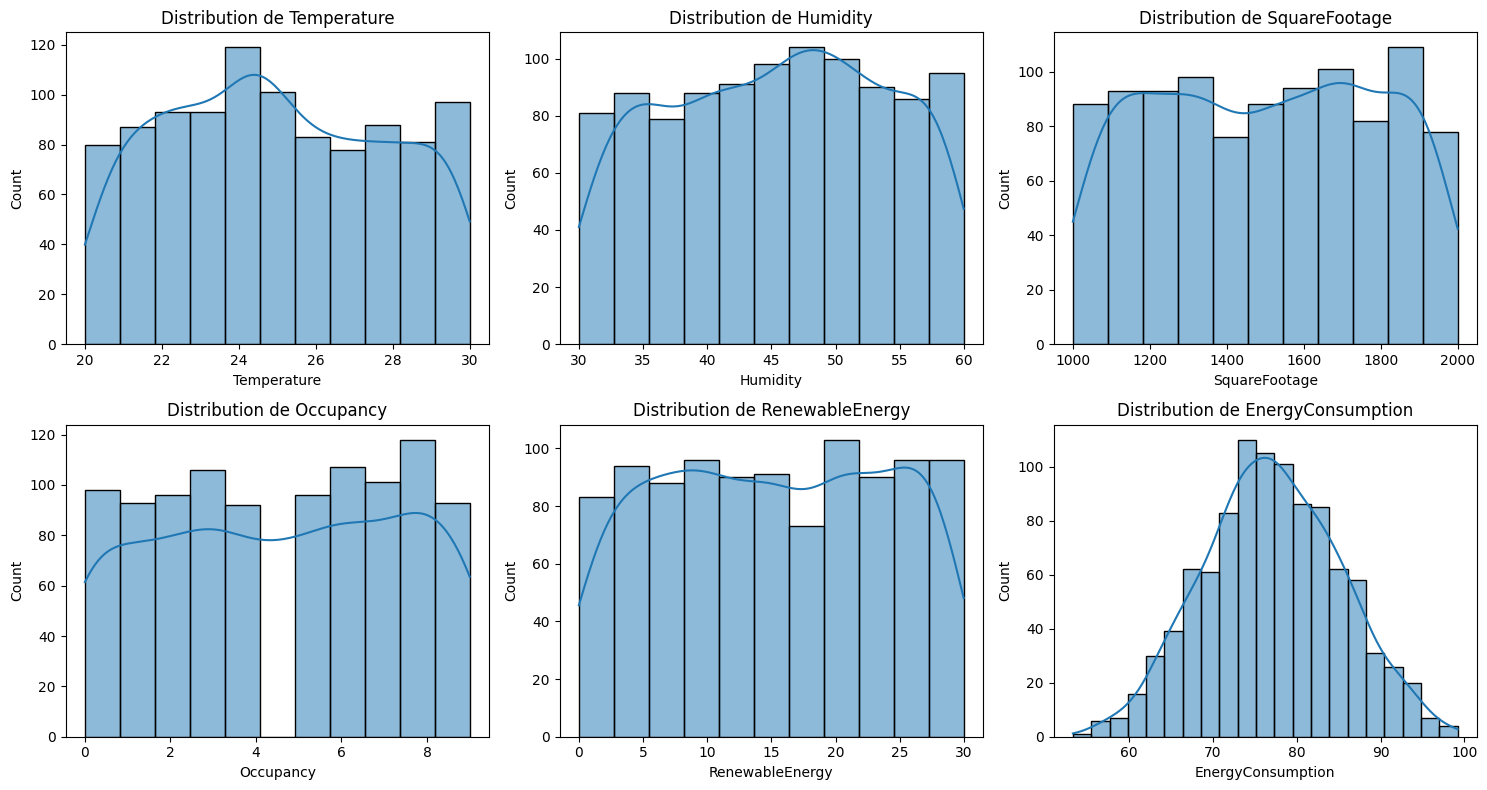

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution de {col}')
plt.tight_layout()
plt.show()

In [11]:
skew_kurt = pd.DataFrame({
    'skewness': df[num_cols].skew(),
    'kurtosis': df[num_cols].kurt()
})
print(skew_kurt)

                   skewness  kurtosis
Temperature        0.088428 -1.115196
Humidity          -0.066463 -1.133748
SquareFootage     -0.019441 -1.229895
Occupancy         -0.055229 -1.233842
RenewableEnergy   -0.021597 -1.220440
EnergyConsumption  0.027399 -0.300154


# Interprétation
Les variables numériques présentent des distributions globalement symétriques (skewness proche de 0) et légèrement applatis (kurtosis négative)

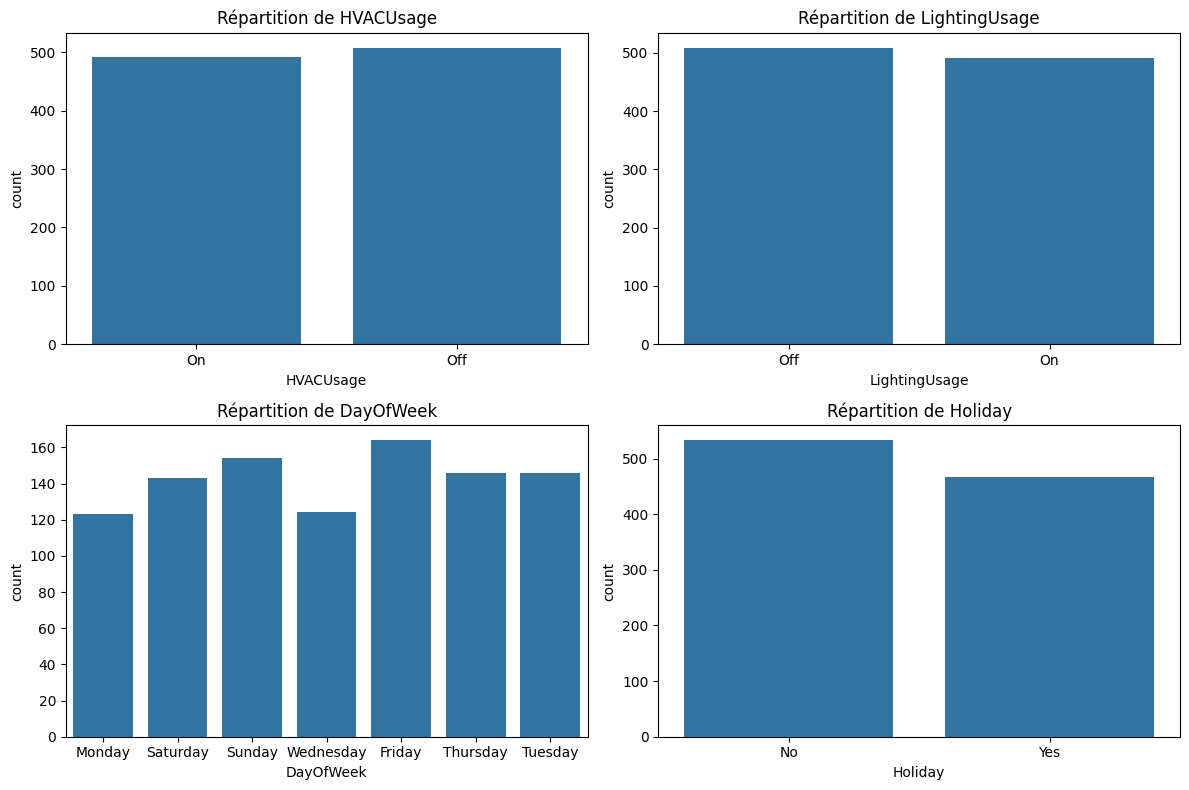

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(f'Répartition de {col}')
plt.tight_layout()
plt.show()

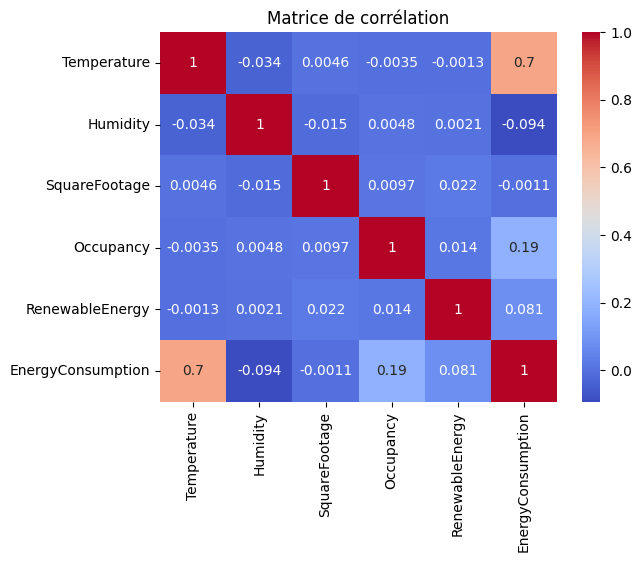

In [13]:
corr = df[num_cols].corr()
sns.heatmap(corr, cmap="coolwarm", annot=True)
plt.title("Matrice de corrélation")
plt.show()

# Interpretation

La température à un coefficent égal à 0.7 et Occupancy 0.19. On conclut que la consommation d'énergie dépendrait de Temperature et Occupancy

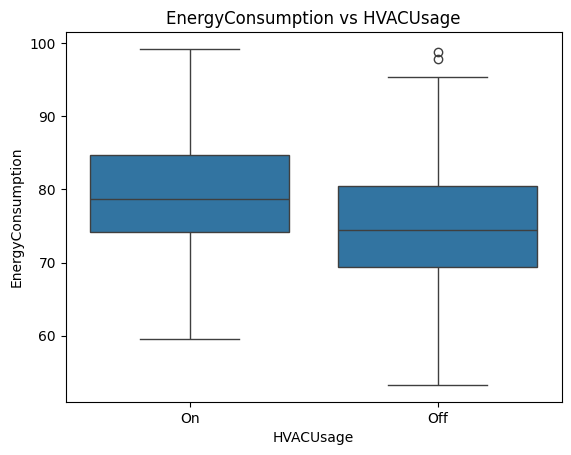

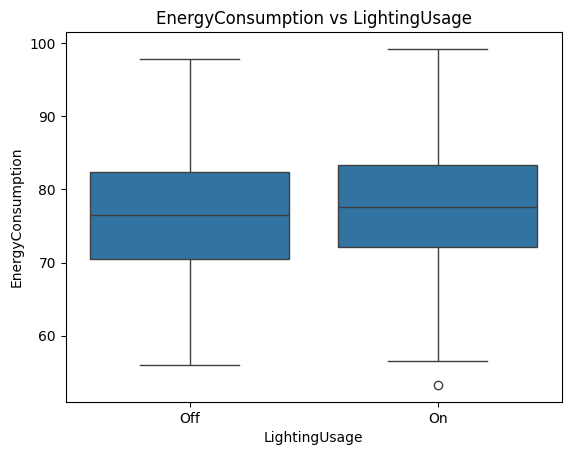

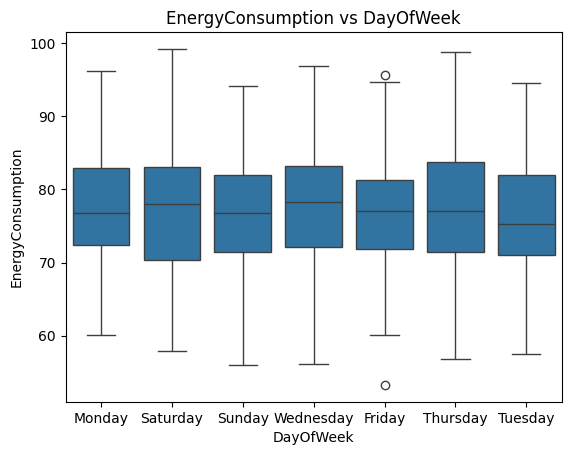

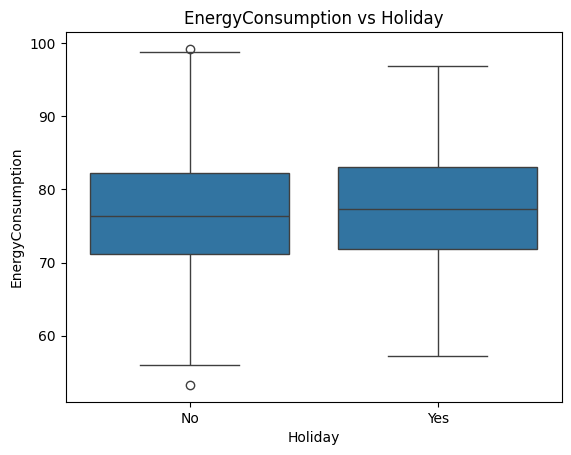

In [14]:
for col in cat_cols:
    sns.boxplot(x=col, y='EnergyConsumption', data=df)
    plt.title(f'EnergyConsumption vs {col}')
    plt.show()

In [15]:
target = 'EnergyConsumption'
   
for col in num_cols:
    if col == target: continue
    r_p, p_p = pearsonr(df[col], df[target])
    print(f"{col} : Coefficient = {r_p:.2f}, p-value = {p_p:.4f}")

Temperature : Coefficient = 0.70, p-value = 0.0000
Humidity : Coefficient = -0.09, p-value = 0.0031
SquareFootage : Coefficient = -0.00, p-value = 0.9716
Occupancy : Coefficient = 0.19, p-value = 0.0000
RenewableEnergy : Coefficient = 0.08, p-value = 0.0102


Le test de pearson confirme notre hypothèse selon laquelle la consommation d'énergie dépendrait de la température et du nombre d'occupants

In [16]:
for col in cat_cols:
    groupes = [df[df[col]==val]['EnergyConsumption'] for val in df[col].unique()]
    f_stat, p_value = f_oneway(*groupes)
    print(f"{col} : F={f_stat:.2f}, p-value={p_value:.4f}")

HVACUsage : F=89.22, p-value=0.0000
LightingUsage : F=8.79, p-value=0.0031
DayOfWeek : F=0.32, p-value=0.9290
Holiday : F=3.22, p-value=0.0732


On déduit que HVACUsage et LightingUsage influence la consommation d'énergie

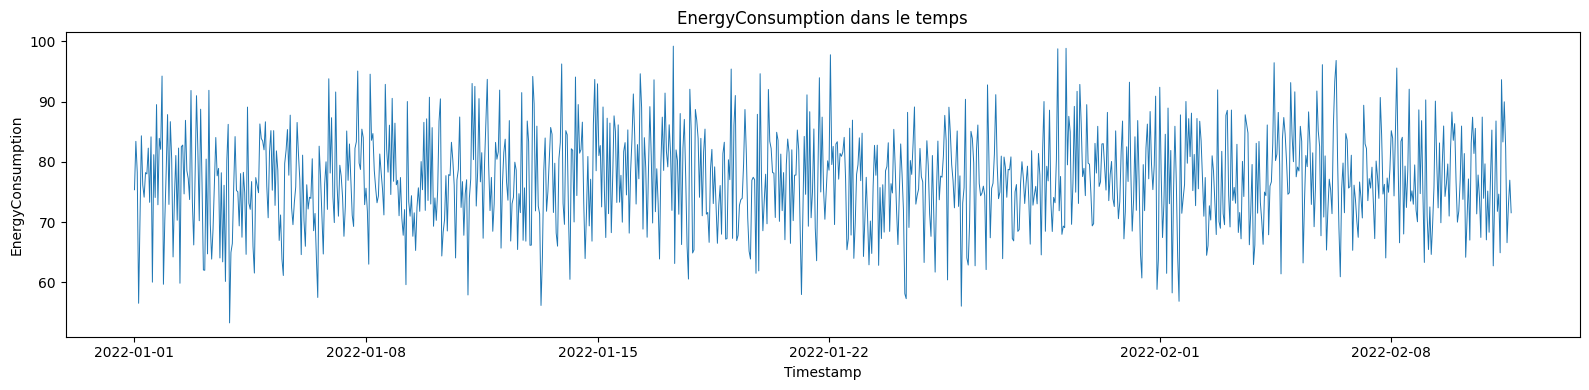

In [17]:
df_sorted = df.sort_values('Timestamp').reset_index(drop=True)
plt.figure(figsize=(16, 4))
plt.plot(df_sorted['Timestamp'], df_sorted['EnergyConsumption'], linewidth=0.7)
plt.title('EnergyConsumption dans le temps')
plt.xlabel('Timestamp')
plt.ylabel('EnergyConsumption')
plt.tight_layout()
plt.show()

In [18]:
df_sorted['Hour'] = df_sorted['Timestamp'].dt.hour
df_sorted['Date'] = df_sorted['Timestamp'].dt.date

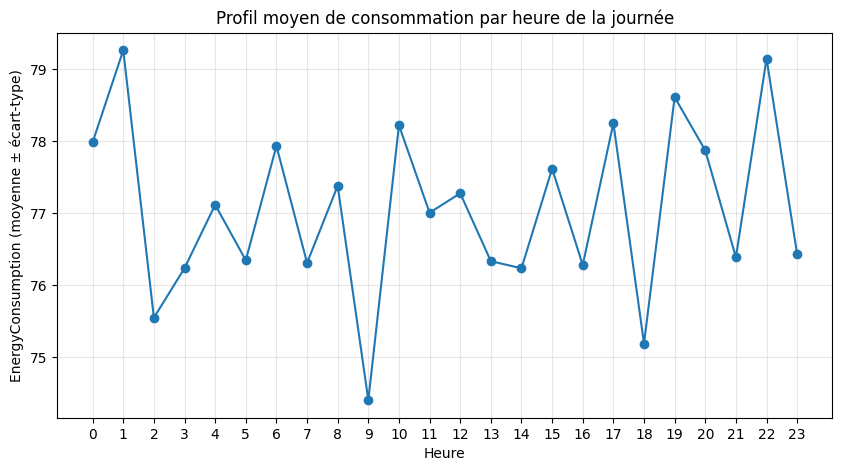

In [19]:
hourly_profile = df_sorted.groupby('Hour')['EnergyConsumption'].agg(['mean', 'std'])

plt.figure(figsize=(10, 5))
plt.plot(hourly_profile.index, hourly_profile['mean'], marker='o')
plt.title('Profil moyen de consommation par heure de la journée')
plt.xlabel('Heure')
plt.ylabel('EnergyConsumption (moyenne ± écart-type)')
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.show()

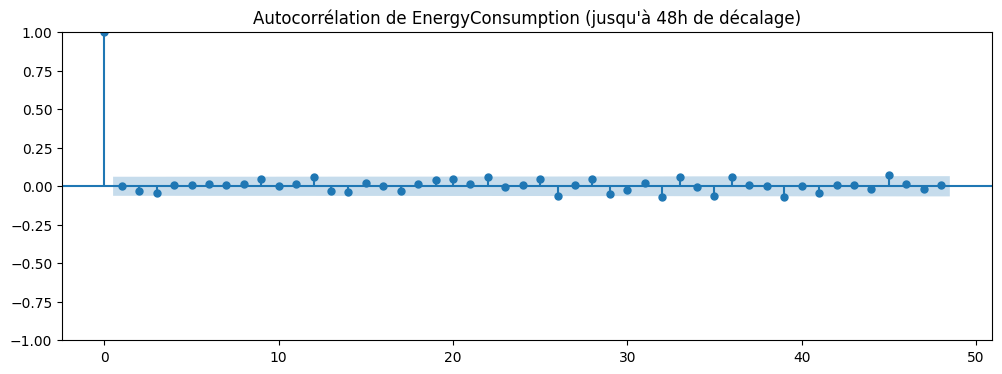

In [20]:
from statsmodels.graphics.tsaplots import plot_acf

series = df_sorted.set_index('Timestamp')['EnergyConsumption']
fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(series, lags=48, ax=ax)
plt.title("Autocorrélation de EnergyConsumption (jusqu'à 48h de décalage)")
plt.show()

L'examen du graphique d'autocorrélation (ACF, jusqu'à 48h de décalage) ne révèle aucune autocorrélation significative : toutes les valeurs restent à l'intérieur de l'intervalle de confiance à 95 %, y compris au lag 24h où un pattern journalier serait normalement attendu pour une consommation énergétique réelle.

In [21]:
df_model = df.copy()

jours_weekend = ['Saturday', 'Sunday']
df_model['DayOfWeek'] = df_model['DayOfWeek'].apply(
    lambda x: 'Weekend' if x in jours_weekend else 'Semaine'
)


df_model = pd.get_dummies(df_model, 
                           columns=['HVACUsage', 'LightingUsage', 'DayOfWeek', 'Holiday'],
                           drop_first=True)

df_model = df_model.drop(columns=['Timestamp'])

In [22]:
# Séparation des données
X = df_model.drop(columns=['EnergyConsumption'])
y = df_model['EnergyConsumption']

# Scinder en données de test et d'entrainement
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train : {X_train.shape[0]} lignes")
print(f"Test  : {X_test.shape[0]} lignes")

Train : 800 lignes
Test  : 200 lignes


In [23]:
# Standardisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entraînement
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Prédiction
y_pred = model.predict(X_test_scaled)

mae_lr = mean_absolute_error(y_test, y_pred)
r2_lr = r2_score(y_test, y_pred)

print(f"MAE : {mae_lr:.2f}")
print(f"R²  : {r2_lr:.3f}")

MAE : 4.11
R²  : 0.598


In [24]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest :")
print(f"  MAE : {mae_rf:.2f}")
print(f"  R²  : {r2_rf:.3f}")

Random Forest :
  MAE : 4.38
  R²  : 0.545


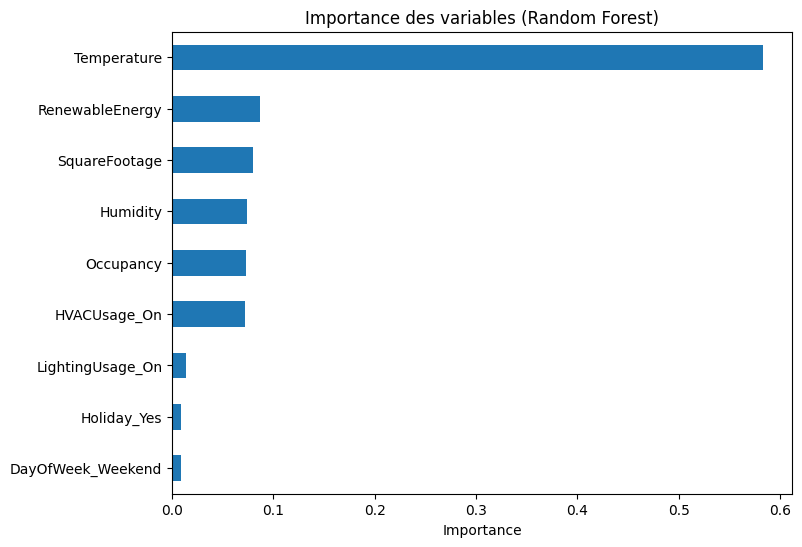

Temperature          0.582736
RenewableEnergy      0.086713
SquareFootage        0.079362
Humidity             0.074129
Occupancy            0.073244
HVACUsage_On         0.072405
LightingUsage_On     0.013954
Holiday_Yes          0.009054
DayOfWeek_Weekend    0.008402
dtype: float64


In [25]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances_triees = importances.sort_values(ascending=False)

plt.figure(figsize=(8,6))
importances_triees.plot(kind='barh')
plt.title('Importance des variables (Random Forest)')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.show()

print(importances_triees)

In [26]:
batiments = X_test.sample(15, random_state=42).reset_index(drop=True)

# prédiction de la consommation
conso_predite = model.predict(batiments)

confort = batiments['Occupancy'].values

print(batiments[['Temperature','Occupancy']].assign(Consommation=conso_predite, Confort=confort))

    Temperature  Occupancy  Consommation  Confort
0     29.132278          9     54.961147        9
1     22.615623          4     73.042855        4
2     20.792398          3     62.143522        3
3     26.209435          1    106.373305        1
4     24.981070          1     25.181823        1
5     26.634832          1     74.010788        1
6     23.190639          3    -12.256172        3
7     27.085200          5     38.129951        5
8     26.760740          4     10.320721        4
9     28.318389          1    112.153282        1
10    24.211587          1     17.431588        1
11    25.271974          9     23.907972        9
12    28.184623          2     19.360404        2
13    25.295159          9     32.683288        9
14    29.934092          2    128.014870        2


/home/fiacre/myenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


In [27]:
n = len(batiments)
budget_total = conso_predite.sum() * 0.7  

model_opt = plp.LpProblem('Allocation_Energie', plp.LpMaximize)

# variable
x = plp.LpVariable.dicts('x', range(n), cat='Binary')

# fonction objectif
model_opt += plp.lpSum(confort[i] * x[i] for i in range(n))

# Contrainte de budget
model_opt += plp.lpSum(conso_predite[i] * x[i] for i in range(n)) <= budget_total

solver = plp.GLPK_CMD(msg=0)
model_opt.solve(solver)

print(f"Statut : {plp.LpStatus[model_opt.status]}")
print(f"Budget disponible : {budget_total:.1f}")
print(f"Consommation utilisée : {sum(conso_predite[i]*x[i].value() for i in range(n)):.1f}")
print(f"Confort total maximisé : {plp.value(model_opt.objective):.0f}")

for i in range(n):
    statut = "activé" if x[i].value() == 1 else "désactivé"
    print(f"Bâtiment {i} : {statut} (conso={conso_predite[i]:.1f}, confort={confort[i]})")

Statut : Optimal
Budget disponible : 535.8
Consommation utilisée : 529.5
Confort total maximisé : 52
Bâtiment 0 : activé (conso=55.0, confort=9)
Bâtiment 1 : activé (conso=73.0, confort=4)
Bâtiment 2 : activé (conso=62.1, confort=3)
Bâtiment 3 : désactivé (conso=106.4, confort=1)
Bâtiment 4 : activé (conso=25.2, confort=1)
Bâtiment 5 : activé (conso=74.0, confort=1)
Bâtiment 6 : activé (conso=-12.3, confort=3)
Bâtiment 7 : activé (conso=38.1, confort=5)
Bâtiment 8 : activé (conso=10.3, confort=4)
Bâtiment 9 : désactivé (conso=112.2, confort=1)
Bâtiment 10 : désactivé (conso=17.4, confort=1)
Bâtiment 11 : activé (conso=23.9, confort=9)
Bâtiment 12 : activé (conso=19.4, confort=2)
Bâtiment 13 : activé (conso=32.7, confort=9)
Bâtiment 14 : activé (conso=128.0, confort=2)
